In [1]:
import numpy as np

import os

import xarray as xr

import glob

import matplotlib.pyplot as plt

import pandas as pd

from matplotlib.colors import BoundaryNorm

import matplotlib.colors as mcolors

import dask.array as da

import pickle

In [2]:
# reading in ERA5 to compare

base_path = '/data/rong4/Data/ERA5/3hourly/quvw_US'

# Define the range of years and months
years = [str(year) for year in range(1979, 2019)]

def get_files(folder, component):

    files = glob.glob(os.path.join(base_path, folder, f"era5.{component}.*.nc"))

    filtered_files = [f for f in files if any(year in f for year in years)]
    
    return filtered_files

# Get the files for each component
u_files = get_files('u_component_of_wind', 'u_component_of_wind')

v_files = get_files('v_component_of_wind', 'v_component_of_wind')

q_files = get_files('specific_humidity', 'specific_humidity')

w_files = get_files('vertical_velocity', 'vertical_velocity')

all_files = u_files + v_files + q_files + w_files

# open all datasets at once
era5 = xr.open_mfdataset(all_files, combine='by_coords', chunks={'time': 24})

era5sgp = era5.sel(latitude=slice(39.0, 30.0), longitude=slice(-105.0, -95.0))

era5sgp['time'] = era5sgp['time'] - pd.Timedelta(hours=6)

In [3]:
#subsetting for 2011

era2011 = era5sgp.where(era5sgp['time'].dt.year == 2011, drop=True)

night = era2011.sel(time=era2011['time'].dt.hour.isin([0, 6]))

day = era2011.sel(time=era2011['time'].dt.hour.isin([12, 18]))

full = era2011.sel(time=era2011['time'].dt.hour.isin([0, 6, 12, 18]))

night = night.resample(time='ME').mean()

day = day.resample(time='ME').mean()

full = full.resample(time='ME').mean()

In [4]:
#subsetting for climatology

clim = era5sgp.sel(time=slice('1979-01-01', '2018-12-31'))

cnight = clim.sel(time=clim['time'].dt.hour.isin([0, 6]))

cday = clim.sel(time=clim['time'].dt.hour.isin([12, 18]))

cfull = clim.sel(time=clim['time'].dt.hour.isin([0, 6, 12, 18]))

cnight = cnight.groupby('time.month').mean('time')

cday = cday.groupby('time.month').mean('time')

cfull = cfull.groupby('time.month').mean('time')

In [5]:
all_times = {
    
#     'clim full': cfull,
    
    '2011 night': night,
    
    '2011 day': day
        
#     'clim night': cnight,
    
#     'clim day': cday 
    
}

In [10]:
def calculate_vertical_advection_new(w, q, pressure, lat, lon):
    
    R = 6371000  # radius of Earth (meters)
    
    rho_water = 1000  # kg/m^3
    
    seconds_to_day = 60 * 60 * 24  # to convert from s --> day

    # Grid spacing and corrections
    dphi = np.radians(lat[1]) - np.radians(lat[0])
    
    dtheta = np.radians(lon[1]) - np.radians(lon[0])
    
    lon_grid, lat_grid = np.meshgrid(np.radians(lon), np.radians(lat))

    dx = R * dtheta * np.cos(lat_grid)  
    
    dy = R * dphi                   
    
    grid_area = dx * dy                # Area of each grid cell (lat, lon)
        
    # Initialize the vertical gradient array
    dq_dp = np.zeros_like(q)

    # Compute vertical gradient of specific humidity (dq/dp)
    for j in range(1, q.shape[0] - 1):  # Central differencing for interior levels
        
        dq_dp[j, :, :] = (q[j - 1, :, :] - q[j + 1, :, :]) / (pressure[j - 1] - pressure[j + 1])

    # Forward/backward differencing for boundaries
    dq_dp[0, :, :] = (q[0, :, :] - q[1, :, :]) / (pressure[0] - pressure[1])
    
    dq_dp[-1, :, :] = (q[-2, :, :] - q[-1, :, :]) / (pressure[-2] - pressure[-1])

    # Vertical advection term: -omega * dq/dp
    vertical_advection = -(w * dq_dp)  # Shape = (levels, lat, lon)
    
    A = np.sum(grid_area)
    
    # Area-weighted average across the domain for each pressure level
    vertical_advection_area_weighted = np.sum(vertical_advection * grid_area, axis=(1, 2)) / A

    # Convert to mm/day
    vertical_advection_area_weighted *= seconds_to_day   

    return vertical_advection_area_weighted

In [27]:
def calculate_horizontal_advection_new(u, v, q, lat, lon):

    R = 6371000  # Earth's radius in meters
    
    seconds_to_day = 60 * 60 * 24  # convert from seconds to days

    # Convert lat/lon to radians
    lat_rad = np.radians(lat)  # φ (phi) — latitude
    
    lon_rad = np.radians(lon)  # θ (theta) — longitude

    # Grid spacing in radians
    dphi = lat_rad[1] - lat_rad[0]     # meridional spacing (north-south)
    
    dtheta = lon_rad[1] - lon_rad[0]   # zonal spacing (east-west)

    # Create 2D meshgrid of lat/lon in radians
    lon_grid, lat_grid = np.meshgrid(lon_rad, lat_rad)
    
    # Grid cell dimensions
    dx = R * dtheta * np.cos(lat_grid)   # zonal grid spacing (varies with latitude)
    
    dy = R * dphi                        # meridional spacing (constant)

    # Area of each grid cell
    grid_area = dx * dy  # shape: (lat, lon)
    
    # Initialize gradients of q
    dq_dtheta = np.zeros_like(q)  # zonal derivative ∂q/∂θ
    
    dq_dphi = np.zeros_like(q)    # meridional derivative ∂q/∂φ

    # Loop through each pressure level
    for k in range(q.shape[0]):
        # Zonal derivative (x-direction, longitude)
        dq_dtheta[k, :, 1:-1] = (q[k, :, 2:] - q[k, :, :-2]) / (2 * dtheta)
        
        dq_dtheta[k, :, 0] = (q[k, :, 1] - q[k, :, 0]) / dtheta
        
        dq_dtheta[k, :, -1] = (q[k, :, -2] - q[k, :, -1]) / dtheta

        # Meridional derivative (y-direction, latitude)
        
        dq_dphi[k, 1:-1, :] = (q[k, 2:, :] - q[k, :-2, :]) / (2 * dphi)
        
        dq_dphi[k, 0, :] = (q[k, 1, :] - q[k, 0, :]) / dphi
        
        dq_dphi[k, -1, :] = (q[k, -2, :] - q[k, -1, :]) / dphi

    # Compute advection terms using spherical coordinates
    # Note: sin(lat) and cos(lat) come from geometry of spherical Earth
    
    zonal_advection = -(u * dq_dtheta) / (R * np.cos(lat_grid))
    
    meridional_advection = -(v * dq_dphi) / (R)

    # Multiply by grid area to get total contribution
    weighted_zonal = zonal_advection * grid_area
    
    weighted_meridional = meridional_advection * grid_area
    
    # Total area of the domain
    A = np.sum(grid_area)

    # Area-weighted average for each pressure level, scaled to mm/day
    zonal_adv_avg = np.sum(weighted_zonal, axis=(1, 2)) / A * seconds_to_day
    
    meridional_adv_avg = np.sum(weighted_meridional, axis=(1, 2)) / A * seconds_to_day

    return zonal_adv_avg, meridional_adv_avg


In [28]:
def calculate_horizontal_convergence_new(u, v, q, lat, lon):
    
    R = 6371000  # Earth's radius in meters
    
    rho_water = 1000  # kg/m³
    
    seconds_to_day = 60 * 60 * 24  # conversion from seconds to days

    # Convert latitude and longitude to radians
    lat_rad = np.radians(lat)
    
    lon_rad = np.radians(lon)

    # Grid spacing (in radians)
    dphi = lat_rad[1] - lat_rad[0]      # north-south spacing
    
    dtheta = lon_rad[1] - lon_rad[0]    # east-west spacing

    # Meshgrid for lat/lon
    lon_grid, lat_grid = np.meshgrid(lon_rad, lat_rad)
    
    cos_lat = np.cos(lat_grid)

    # Grid cell dimensions

    dx = R * dtheta * cos_lat
    
    dy = R * dphi              # meridional height (constant)

    # Area of each grid cell
    grid_area = dx * dy

    # scale v by cos(latitude) for spherical divergence
    v_scaled = v * cos_lat[np.newaxis, :, :]
    
    # initialize gradient arrays
    du_dtheta = np.zeros_like(u)  # ∂u/∂λ
    
    dv_dphi = np.zeros_like(v)    # ∂(v·sinφ)/∂φ

    # Compute zonal and meridional derivatives at each pressure level
    for k in range(u.shape[0]):
        
        # Zonal derivative (longitude direction)
        du_dtheta[k, :, 1:-1] = (u[k, :, 2:] - u[k, :, :-2]) / (2 * dtheta)
        
        du_dtheta[k, :, 0] = (u[k, :, 1] - u[k, :, 0]) / dtheta
        
        du_dtheta[k, :, -1] = (u[k, :, -2] - u[k, :, -1]) / dtheta

        # Meridional derivative (latitude direction)
        
        dv_dphi[k, 1:-1, :] = (v_scaled[k, 2:, :] - v_scaled[k, :-2, :]) / (2 * dphi)
        
        dv_dphi[k, 0, :] = (v_scaled[k, 1, :] - v_scaled[k, 0, :]) / dphi
        
        dv_dphi[k, -1, :] = (v_scaled[k, -2, :] - v_scaled[k, -1, :]) / dphi

    # Spherical coordinate divergence of wind (scaled by q)
    zonal_convergence = -(q * du_dtheta) / (R * cos_lat[np.newaxis, :, :])
        
    meridional_convergence = -(q * dv_dphi) / (R * cos_lat[np.newaxis, :, :])

    # Multiply by grid area for area-weighted sum
    weighted_zonal = zonal_convergence * grid_area
    
    weighted_meridional = meridional_convergence * grid_area

    # Area-weighted average convergence per level
    
    A = np.sum(grid_area)
    
    zonal_convergence = np.sum(weighted_zonal, axis=(1, 2)) / A * seconds_to_day
    
    meridional_convergence = np.sum(weighted_meridional, axis=(1, 2)) / A * seconds_to_day
    
    # Units: 1/day
    return zonal_convergence, meridional_convergence

In [29]:
u_hov = full['u'].load().data[:, :, ::-1, :]
print("u loaded")

v_hov = full['v'].load().data[:, :, ::-1, :]
print("v loaded")

q_hov = full['q'].load().data[:, :, ::-1, :] 
print("q loaded")

w_hov = full['w'].load().data[:, :, ::-1, :] 
print("w loaded")

pressure = full['level'].data * 100

u loaded
v loaded
q loaded
w loaded


## calculate advection

In [30]:
levels = cfull['level'].data * 100 

latitude = cfull['latitude'].data[::-1]

longitude = cfull['longitude'].data

# to append

zonal_advection_profile = []

meridional_advection_profile = []

vertical_advection_profile = []

# looping over every month

months = u_hov.shape[0]

for i in range(months):

    # advection
    zonal_adv, merid_adv = calculate_horizontal_advection_new(u_hov[i], v_hov[i], q_hov[i], latitude, longitude)
    
    vertical_adv = calculate_vertical_advection_new(w_hov[i], q_hov[i], pressure, latitude, longitude)
        
    # append advection
    zonal_advection_profile.append(zonal_adv)
    
    meridional_advection_profile.append(merid_adv)
    
    vertical_advection_profile.append(vertical_adv)
    
zonal_advection_profile = np.array(zonal_advection_profile)

meridional_advection_profile = np.array(meridional_advection_profile)

vertical_advection_profile = np.array(vertical_advection_profile)

## calculate convergence

In [33]:
levels = cfull['level'].data * 100 

latitude = cfull['latitude'].data[::-1]

longitude = cfull['longitude'].data

# to append

zonal_convergence_profile = []

meridional_convergence_profile = []

# Looping over every month
months = u_hov.shape[0]

for i in range(months):

    # advection
    zonal_conv, merid_conv = calculate_horizontal_convergence_new(u_hov[i], v_hov[i], q_hov[i], latitude, longitude)
        
    # append advection
    zonal_convergence_profile.append(zonal_conv)
    
    meridional_convergence_profile.append(merid_conv)
    
zonal_convergence_profile = np.array(zonal_convergence_profile)

meridional_convergence_profile = np.array(meridional_convergence_profile)

## plotting advection Hovmoller diagrams below

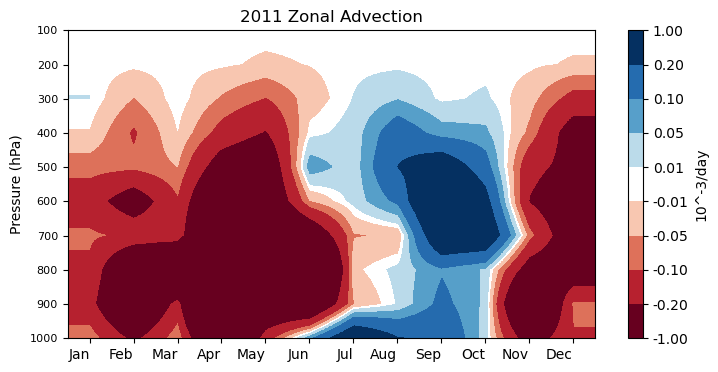

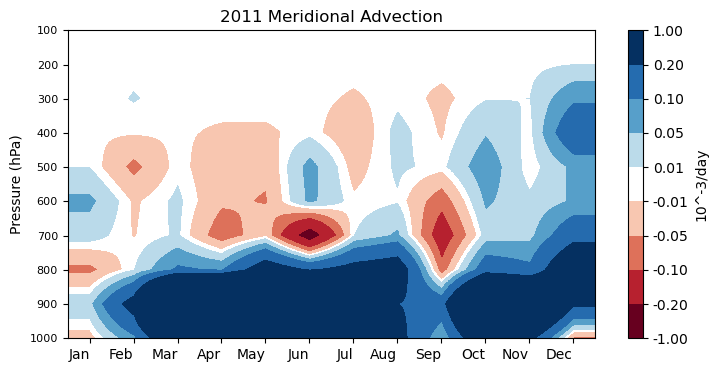

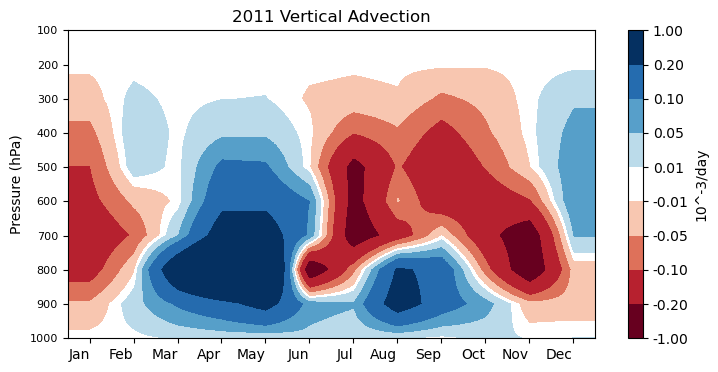

In [31]:
profs_to_plot = [zonal_advection_profile*1000, meridional_advection_profile*1000, vertical_advection_profile*1000]

# Plotting the Hovmoller diagram of zonal and meridional advection 

titles = ['Zonal', 'Meridional', 'Vertical']

pressure_levels = full['level'].data

# levels = np.linspace(-2.5, 2.5, 10)

# colors = ['#67001f', '#b2182b', '#d6604d', '#f4a582', 'white', 'white', '#92c5de', '#4393c3', '#2166ac', '#053061']

levels = np.array([-1, -0.2, -0.1, -0.05, -0.01, 0.01, 0.05, 0.1, 0.2, 1])

# levels = np.linspace(-1.5, 1.5, 10)

colors = ['#67001f', '#b2182b', '#d6604d', '#f4a582', 'white', 'white', '#92c5de', '#4393c3', '#2166ac', '#053061']

cmap = mcolors.LinearSegmentedColormap.from_list("custom_coolwarm", colors, N=len(levels) - 1)

norm = mcolors.BoundaryNorm(levels, ncolors=len(levels) - 1, clip=True)

# Subset pressure levels and data to go up to 100 hPa
pressure_subset = pressure_levels[(pressure_levels >= 100) & (pressure_levels % 100 == 0)]

pressure_indices = np.isin(pressure_levels, pressure_subset).nonzero()[0]  # Indices for data subsetting

for i, arr in enumerate(profs_to_plot):
    
    plt.figure(figsize=(8.5, 4))
    
    # Subset data to match the pressure range up to 100 hPa
    hovmoller_data = np.array(arr)[:, pressure_indices]

    # Plot data without forcing extent to allow automatic scaling
    plt.imshow(hovmoller_data.T, aspect='auto', origin='lower', cmap=cmap, norm=norm, interpolation='bilinear')
    
    # Set x-axis labels
    plt.xticks(np.arange(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
               ha='right')
    
    # Directly use the pressure subset for y-axis labels
    plt.yticks(np.arange(len(pressure_subset)), pressure_subset, size=8)
    
    plt.ylim(0, len(pressure_subset) - 1)  # Reverse to show top level first

    plt.ylabel('Pressure (hPa)')

    # Color bar with custom tick labels
    cbar = plt.colorbar(label='10^-3/day', ticks=levels)
    
    cbar.ax.set_yticklabels(['<-0.2', '-0.2', '-0.1', '-0.05', '-0.01', '0.01', '0.05', '0.1', '0.2', '>0.2'])

    cbar.ax.set_yticklabels([f"{level:.2f}" for level in levels])

    # Set title and show plot
    plt.title('2011 {} Advection'.format(titles[i]))
    
    plt.gca().invert_yaxis()
    
    plt.show()

## plotting convergence Hovmoller diagrams below

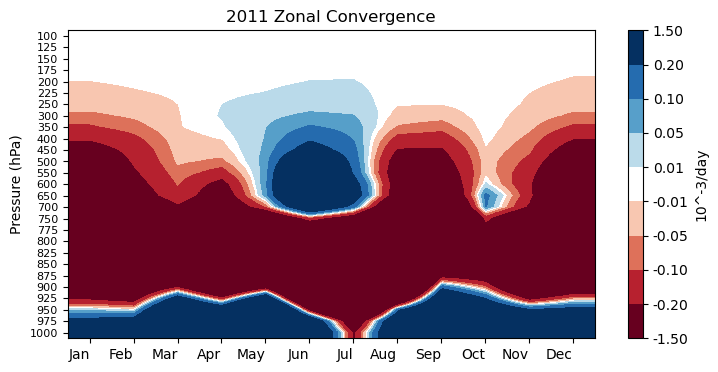

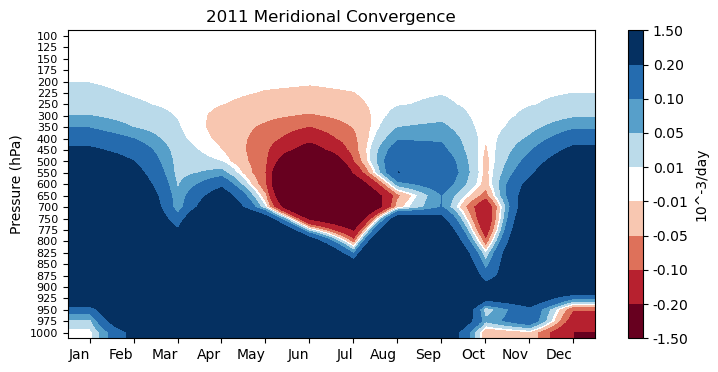

In [37]:
profs_to_plot = [zonal_convergence_profile*1000, meridional_convergence_profile*1000]

# Plotting the Hovmoller diagram of zonal and meridional advection 

titles = ['Zonal', 'Meridional']

pressure_levels = full['level'].data

# colors = ['#67001f', '#b2182b', '#d6604d', '#f4a582', 'white', 'white', '#92c5de', '#4393c3', '#2166ac', '#053061']

# levels = np.array([-1.5, -0.2, -0.1, -0.05, -0.01, 0.01, 0.05, 0.1, 0.2, 1.5])

levels = np.array([-1.5, -0.2, -0.1, -0.05, -0.01, 0.01, 0.05, 0.1, 0.2, 1.5])

colors = ['#67001f', '#b2182b', '#d6604d', '#f4a582', 'white', 'white', '#92c5de', '#4393c3', '#2166ac', '#053061']

cmap = mcolors.LinearSegmentedColormap.from_list("custom_coolwarm", colors, N=len(levels) - 1)

norm = mcolors.BoundaryNorm(levels, ncolors=len(levels) - 1, clip=True)

# Subset pressure levels and data to go up to 100 hPa
pressure_subset = pressure_levels[pressure_levels >= 100]

pressure_indices = np.where(pressure_levels >= 100)[0]  # Get indices for subsetting the data

for i, arr in enumerate(profs_to_plot):
    
    plt.figure(figsize=(8.5, 4))
    
    # Subset data to match the pressure range up to 100 hPa
    hovmoller_data = np.array(arr)[:, pressure_indices]

    # Plot data without forcing extent to allow automatic scaling
    plt.imshow(hovmoller_data.T, aspect='auto', origin='lower', cmap=cmap, norm=norm, interpolation='bilinear')
    
    # Set x-axis labels
    plt.xticks(np.arange(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
               ha='right')
    
    # Directly use the pressure subset for y-axis labels
    plt.yticks(np.arange(len(pressure_subset)), pressure_subset, size=8)

    plt.ylabel('Pressure (hPa)')

    # Color bar with custom tick labels
    cbar = plt.colorbar(label='10^-3/day', ticks=levels)
    
    cbar.ax.set_yticklabels(['<-0.2', '-0.2', '-0.1', '-0.05', '-0.01', '0.01', '0.05', '0.1', '0.2', '>0.2'])

    cbar.ax.set_yticklabels([f"{level:.2f}" for level in levels])

    # Set title and show plot
    plt.title('2011 {} Convergence'.format(titles[i]))
    
    plt.gca().invert_yaxis()
    
    plt.show()

In [42]:
def vertically_integrated_advection(u, v, q, levels, lat, lon):
    
    g = 9.81  # Gravitational acceleration in m/s^2
    
    rho_water = 1000  # Density of water in kg/m^3
    
    mm_to_m = 1000

    # Get the moisture budget profiles
    zonal_advection_area_weighted, meridional_advection_area_weighted = calculate_horizontal_advection_new(u, v, q, lat, lon)
    
    # Calculate dp, with the sign depending on your dataset's vertical structure
    dp = np.diff(levels)
    
    # Create a dictionary to store the input profiles and the integrated results
    profiles = {
        "zonal_advection_integrated": zonal_advection_area_weighted,
        "meridional_advection_integrated": meridional_advection_area_weighted,
    }
    
    
    integrated_results = {}  # Dictionary to store integrated results
    
    for name, profile in profiles.items():
                
        integrated_results[name] = (np.sum(0.5 * (profile[:-1] + profile[1:]) * dp) / (g * rho_water)) * 1000

    return integrated_results

In [38]:
def vertically_integrated_convergence(u, v, q, levels, lat, lon):
    
    g = 9.81  # Gravitational acceleration in m/s^2
    
    rho_water = 1000  # Density of water in kg/m^3
    
    mm_to_m = 1000

    # Get the moisture budget profiles
    zonal_convergence_area_weighted, meridional_convergence_area_weighted = calculate_horizontal_convergence_new(u, v, q, lat, lon)
    
    # Calculate dp, with the sign depending on your dataset's vertical structure
    dp = np.diff(levels)
    
    # Create a dictionary to store the input profiles and the integrated results
    profiles = {
        "zonal_convergence_integrated": zonal_convergence_area_weighted,
        "meridional_convergence_integrated": meridional_convergence_area_weighted,
    }
    
    
    integrated_results = {}  # Dictionary to store integrated results
    
    for name, profile in profiles.items():
                
        integrated_results[name] = (np.sum(0.5 * (profile[:-1] + profile[1:]) * dp) / (g * rho_water)) * 1000

    return integrated_results

In [43]:
integrated_advection_results = {}  # Main dictionary to store results for all datasets

integrated_convergence_results = {}

for df_name, df in all_times.items():
    
    print(df_name)
    
    identifier = df_name
    
    u_int = df['u'].load().data[:, :, ::-1, :] 
    print("u loaded")
    
    v_int = df['v'].load().data[:, :, ::-1, :]
    print("v loaded")
        
    q_int = df['q'].load().data[:, :, ::-1, :] 
    print("q loaded")
    
    levels = df['level'].data * 100 
    
    lat = df['latitude'].data[::-1]
    
    lon = df['longitude'].data
    
    months = u_int.shape[0]
    
    integrated_advection_results[df_name] = {
        "zonal adv": [],
        "merid adv": []
    }
    
    integrated_convergence_results[df_name] = {
        "zonal conv": [],
        "merid conv": []
    }
    
    # Loop over every month 
    for i in range(months):

        advection_results = vertically_integrated_advection(u_int[i], v_int[i], q_int[i], levels, lat, lon)
        
        convergence_results = vertically_integrated_convergence(u_int[i], v_int[i], q_int[i], levels, lat, lon)

        # Append the results to the corresponding lists
        integrated_advection_results[df_name]["zonal adv"].append(advection_results["zonal_advection_integrated"])
        
        integrated_advection_results[df_name]["merid adv"].append(advection_results["meridional_advection_integrated"])
        
        # Append the results to the corresponding lists
        integrated_convergence_results[df_name]["zonal conv"].append(convergence_results["zonal_convergence_integrated"])
        
        integrated_convergence_results[df_name]["merid conv"].append(convergence_results["meridional_convergence_integrated"])
        
        

2011 night
u loaded
v loaded
q loaded
2011 day
u loaded
v loaded
q loaded


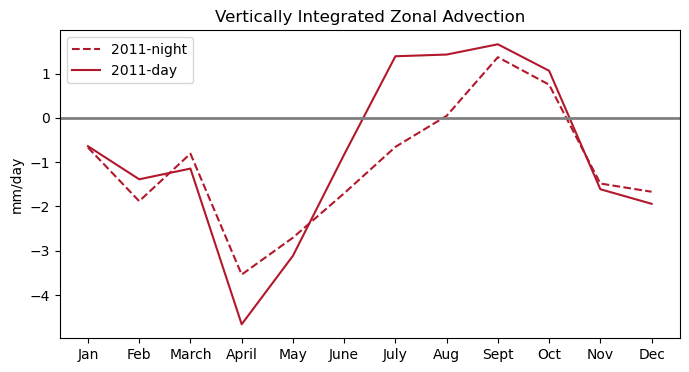

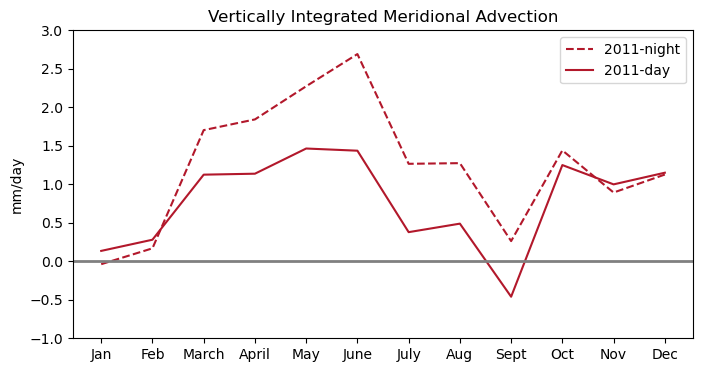

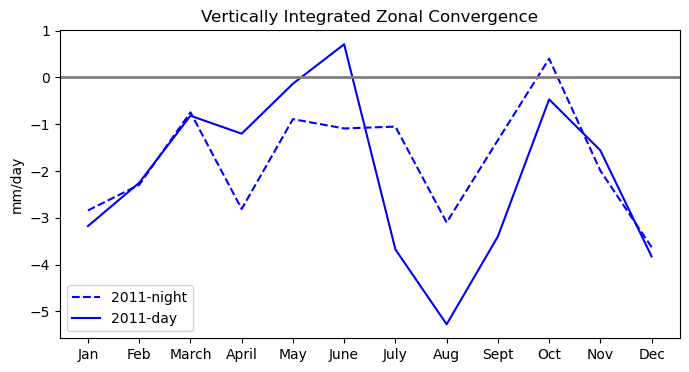

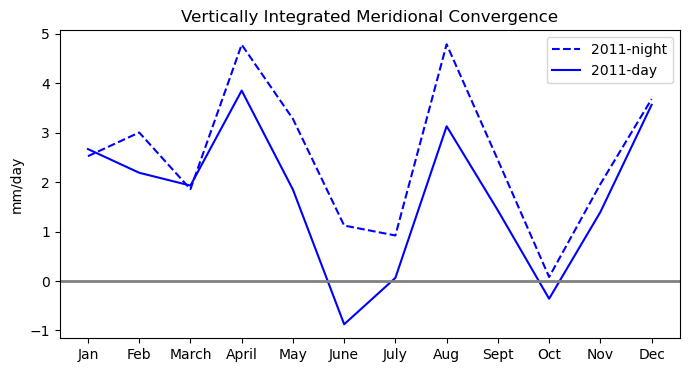

In [46]:
# zonal advection

fig, ax = plt.subplots(figsize=(8, 4))

months=["Jan", "Feb", "March", "April", "May", "June", "July", "Aug", "Sept", "Oct", "Nov", "Dec"]

plt.plot(months, integrated_advection_results['2011 night']['zonal adv'], color='#b2182b', linestyle='--', label='2011-night')

plt.plot(months, integrated_advection_results['2011 day']['zonal adv'], color='#b2182b', label='2011-day')

plt.axhline(0, color='grey', linewidth=2)

plt.ylabel("mm/day")

plt.title("Vertically Integrated Zonal Advection")

# plt.ylim(-5,2)

plt.legend()

plt.show()


# meridional advection

fig, ax = plt.subplots(figsize=(8, 4))

plt.plot(months, integrated_advection_results['2011 night']['merid adv'], color='#b2182b', linestyle='--', label='2011-night')

plt.plot(months, integrated_advection_results['2011 day']['merid adv'], color='#b2182b', label='2011-day')

plt.axhline(0, color='grey', linewidth=2)

plt.title("Vertically Integrated Meridional Advection")

plt.ylabel("mm/day")

plt.ylim(-1,3)

plt.legend()

plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

# zonal convergence

plt.plot(months, integrated_convergence_results['2011 night']['zonal conv'], linestyle='--', label='2011-night', color='blue')

plt.plot(months, integrated_convergence_results['2011 day']['zonal conv'], label='2011-day', color='blue')

plt.axhline(0, color='grey', linewidth=2)

plt.ylabel("mm/day")

plt.title("Vertically Integrated Zonal Convergence")

plt.legend()

plt.show()

fig, ax = plt.subplots(figsize=(8, 4))

# meridional convergence

plt.plot(months, integrated_convergence_results['2011 night']['merid conv'], linestyle='--', label='2011-night', color='blue')

plt.plot(months, integrated_convergence_results['2011 day']['merid conv'], label='2011-day', color='blue')

plt.axhline(0, color='grey', linewidth=2)

plt.ylabel("mm/day")

plt.title("Vertically Integrated Meridional Convergence")

plt.legend()

plt.show()